# Indy framework3.0 gRPC examples

## Config server

In [1]:
from interfaces.control_socket_client import ControlSocketClient, control_data
from interfaces.device_socket_client import DeviceSocketClient, device_data
from interfaces.config_socket_client import ConfigSocketClient, config_data
from interfaces.rtde_socket_client import RTDESocketClient, rtde_data, common_data

import common as common
import time

ip = '192.168.0.144'
control = ControlSocketClient(ip)
device = DeviceSocketClient(ip)
config = ConfigSocketClient(ip)
rtde = RTDESocketClient(ip)

Failed to import fcntl - CRI disabled


[INFO] 2025-03-24 09:37:48,702, Logger Started


You have more than 100 log files. Attempt to remove.


In [2]:
from enum import Enum

In [3]:
import os
import numpy as np

In [4]:
file_dir = "/home/user/release/IndyDeployment/ProgramScripts/test2.indy7.json"
file_name = os.path.basename(file_dir)

In [19]:
GAIN_INCREMENT_DEFAULT = 100
GAIN_CONVERGENCE_DEFAULT = 5
ROBOT_DOF = 6
JERK_REF_RATIO = 1.1

SW_JPOS_FOLLOW_ERROR = 0x1
ISO_JVEL_LIMIT = 0x100
ISO_JTAU_LIMIT = 0x200

In [20]:
gain_set = config.GetJointControlGain()
gain_kl2 = np.array(gain_set['kl2'])
gain_increment = np.array([GAIN_INCREMENT_DEFAULT]*ROBOT_DOF)
gain_convergence_threshold = GAIN_CONVERGENCE_DEFAULT;
gain_kl2_lb = gain_kl2
gain_kl2_ub = gain_kl2 + gain_increment

control.SetPluginBoolVariable("autotune.reset", True)
control.SetPluginBoolVariable("autotune.active", True)
control.PlayProgram(file_name)
while(rtde.GetProgramData()['program_state'] == common_data.PROG_RUNNING):
    time.sleep(0.02)
    e_rn_jerk_max = control.GetPluginJPosVariable("autotune.eRNjerkMax")['jpos']
if rtde.GetProgramData()['program_state'] != common_data.PROG_IDLE:
    print(f"Fail: program run state fail {rtde.GetProgramData()['program_state']}")
control.SetPluginBoolVariable("autotune.active", False)

q_err_std = control.GetPluginJPosVariable("autotune.qErrStd")['jpos']
e_rn_jerk_max_ref = np.multiply(e_rn_jerk_max, JERK_REF_RATIO)
print(f"error jerk ref: {e_rn_jerk_max_ref}")

error jerk ref: [1.77819697 1.62736937 1.75237524 1.62584884 1.52307056 1.56659107]


In [21]:
q_err_std

[0.0006366138,
 0.00033907942,
 0.0002579336,
 0.00014722916,
 0.00011148477,
 0.00013774265]

In [22]:
gain_log = [gain_kl2]
jerk_log = [e_rn_jerk_max]
qerr_log = [q_err_std]
time_log = [0]
time_0= time.time()
while True:
    control.SetPluginBoolVariable("autotune.reset", True)
    control.SetPluginBoolVariable("autotune.active", True)
    control.PlayProgram(file_name)

    while(rtde.GetProgramData()['program_state'] == common_data.PROG_RUNNING):
        time.sleep(0.005)
        e_rn_jerk_max = control.GetPluginJPosVariable("autotune.eRNjerkMax")['jpos']
        joint_over_threshold = e_rn_jerk_max > e_rn_jerk_max_ref
        if np.any(joint_over_threshold):
            control.StopProgram()
            break

    while(rtde.GetProgramData()['program_state'] != common_data.PROG_IDLE):
        time.sleep(0.5)

    violation_data = rtde.GetViolationData()
    if (int(violation_data['violation_code']) in [SW_JPOS_FOLLOW_ERROR, ISO_JVEL_LIMIT, ISO_JTAU_LIMIT]):
        joint_over_threshold[violation_data['j_index']] = True
        
    if rtde.GetControlData()['op_state'] != common_data.OP_IDLE:
        control.Recover()
        while rtde.GetControlData()['op_state'] != common_data.OP_IDLE:
            time.sleep(1)
            
    if np.any(joint_over_threshold):
        for idx, over_thresh in enumerate(joint_over_threshold):
            if over_thresh:
                print(f"Joint {idx} Over Thresh")
                if gain_increment[idx] < GAIN_CONVERGENCE_DEFAULT:
                    gain_kl2_ub[idx] = gain_kl2_ub[idx] - GAIN_CONVERGENCE_DEFAULT
                    gain_kl2_lb[idx] = gain_kl2_lb[idx] - GAIN_CONVERGENCE_DEFAULT
                else:
                    gain_increment[idx] /= 2
                    if gain_increment[idx] < GAIN_CONVERGENCE_DEFAULT:
                        gain_increment[idx] = 0
                    gain_kl2_ub[idx] = gain_kl2_lb[idx] + gain_increment[idx]
    else:
        print(f"Increment All Gains")
        # increment all bounds
        gain_kl2_lb = gain_kl2_ub
        gain_kl2_ub = gain_kl2_lb + gain_increment
    gain_kl2 = gain_kl2_ub


    if rtde.GetProgramData()['program_state'] != common_data.PROG_IDLE:
        print(f"Fail: program run state fail {rtde.GetProgramData()['program_state']}")
    control.SetPluginBoolVariable("autotune.active", False)    
    q_err_std = control.GetPluginJPosVariable("autotune.qErrStd")['jpos']

    print(f"kl2: {gain_kl2} | jerk: {e_rn_jerk_max}")
    gain_log.append(gain_kl2)
    jerk_log.append(e_rn_jerk_max)
    qerr_log.append(q_err_std)
    time_log.append(time.time()-time_0)
    gain_set['kl2'] = gain_kl2.tolist()
    config.SetJointControlGain(**gain_set)

    if np.all(gain_increment < GAIN_CONVERGENCE_DEFAULT):
        print(f"Final kl2: {gain_kl2}")
        break

Increment All Gains
kl2: [1000. 1000.  800.  600.  600.  600.] | jerk: [1.5362276, 1.4307714, 1.5543238, 1.4552162, 1.4375919, 1.4149055]
Increment All Gains
kl2: [1100. 1100.  900.  700.  700.  700.] | jerk: [1.4787276, 1.3941436, 1.483162, 1.4082555, 1.3789116, 1.3666984]
Increment All Gains
kl2: [1200. 1200. 1000.  800.  800.  800.] | jerk: [1.4641293, 1.3828907, 1.4827552, 1.439616, 1.3476319, 1.3689129]
Joint 3 Over Thresh
kl2: [1200. 1200. 1000.  750.  800.  800.] | jerk: [0.8231515, 0.7926735, 0.9219159, 1.9412413, 1.1854533, 1.4361593]
Joint 3 Over Thresh
kl2: [1200. 1200. 1000.  725.  800.  800.] | jerk: [0.112329334, 0.125877, 0.11175378, 4.007022, 0.21647985, 0.26588368]
Joint 3 Over Thresh
kl2: [1200. 1200. 1000.  712.  800.  800.] | jerk: [0.15302017, 0.10449242, 0.10418162, 3.954757, 0.26989195, 0.25216165]
Joint 3 Over Thresh
kl2: [1200. 1200. 1000.  706.  800.  800.] | jerk: [0.14833209, 0.119459555, 0.16322245, 3.8928509, 0.24671397, 0.24871635]
Joint 3 Over Thresh
kl2

Joint 3 Over Thresh
kl2: [2900. 2900. 1163.  630.  675.  732.] | jerk: [1.2841983, 1.2581445, 1.507872, 1.6431174, 1.294249, 1.2869124]
Joint 2 Over Thresh
kl2: [2900. 2900. 1158.  630.  675.  732.] | jerk: [1.1650566, 1.153176, 1.780324, 1.1221514, 1.4941223, 1.2196895]
Joint 4 Over Thresh
kl2: [2900. 2900. 1158.  630.  670.  732.] | jerk: [1.4098492, 1.3967768, 1.6053131, 1.5034692, 1.5880823, 1.4821857]
Joint 4 Over Thresh
kl2: [2900. 2900. 1158.  630.  665.  732.] | jerk: [1.3898017, 1.3989573, 1.6090211, 1.5741295, 1.5322657, 1.4067683]
Joint 4 Over Thresh
kl2: [2900. 2900. 1158.  630.  660.  732.] | jerk: [1.3918365, 1.3710021, 1.5988255, 1.4451241, 1.5257934, 1.3844019]
Joint 4 Over Thresh
kl2: [2900. 2900. 1158.  630.  655.  732.] | jerk: [1.4325387, 1.3970759, 1.5674919, 1.4902438, 1.525932, 1.4035678]
Joint 4 Over Thresh
kl2: [2900. 2900. 1158.  630.  650.  732.] | jerk: [1.3870319, 1.3534788, 1.5134187, 1.6024127, 1.5271975, 1.4023676]
Increment All Gains
kl2: [3000. 3000. 1

In [25]:
import  matplotlib.pyplot as plt

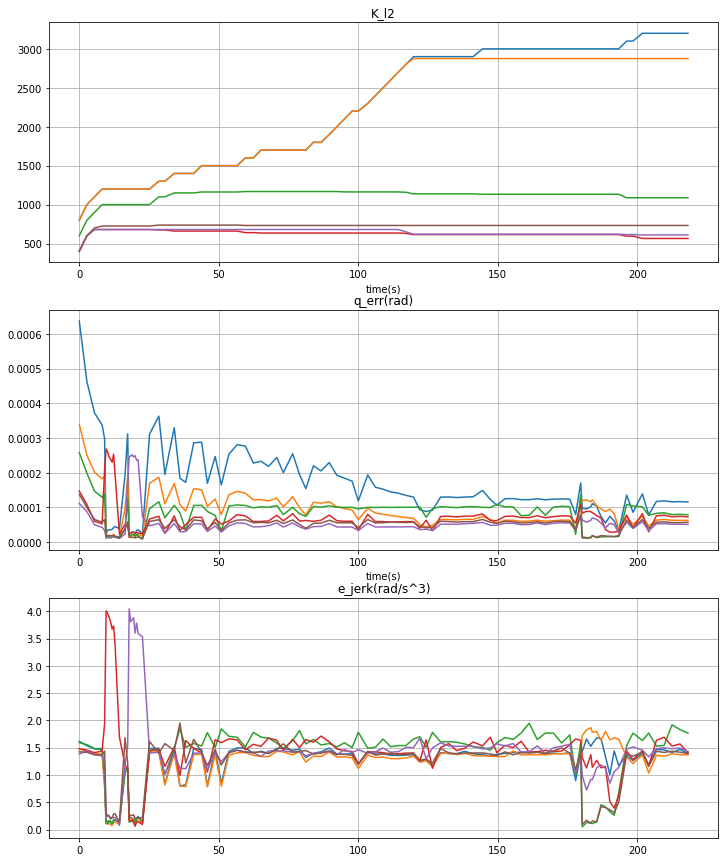

In [46]:
max_iter = 100
plt.figure(figsize=(12,15))
plt.subplot(3,1,1)
plt.title("K_l2")
plt.plot(time_log[:max_iter], gain_log[:max_iter])
plt.xlabel("time(s)")
plt.grid()
plt.subplot(3,1,2)
plt.title("q_err(rad)")
plt.plot(time_log[:max_iter], qerr_log[:max_iter])
plt.xlabel("time(s)")
plt.grid()
plt.subplot(3,1,3)
plt.title("e_jerk(rad/s^3)")
plt.plot(time_log[:max_iter], jerk_log[:max_iter])
plt.grid()

## Default

In [24]:
gain_set = config.GetJointControlGain()
gain_set['kl2'] = [800,800,600,400,400,400]
config.SetJointControlGain(**gain_set)
control.PlayProgram(file_name)

{'code': '0', 'msg': ''}

## Test with Conty protocol

In [6]:

import grpc
from interfaces.impl import hri_msgs_pb2 as conty_data
from interfaces.impl import hri_pb2_grpc as conty_grpc

In [7]:
conty_channel = grpc.insecure_channel("{}:{}".format(ip, 20131))
conty_stub = conty_grpc.HRIStub(conty_channel)

In [8]:
conty_stub.GetNonce(common_data.Empty())

nonce: "2022395958"

In [9]:
digest = config._ConfigSocketClient__config_stub.TestDigest(config_data.Passwd(passwd="nrmk0000"))

In [10]:
token = conty_stub.Login(config_data.Digest(digest=digest.digest)).token

In [11]:
config.VerifyToken(token=token)

{'code': '0', 'msg': ''}

In [12]:
conty_stub.StartAutoTuneControlGain(
    conty_data.PlayProgramReq(file_dir="/home/user/release/IndyDeployment/ProgramScripts/test2.indy7.json"), 
    metadata=[("authorization", f"Bearer {token}")])

In [17]:
config.GetJointControlGain()

{'kp': [100.0, 100.0, 100.0, 100.0, 100.0, 100.0],
 'kv': [20.0, 20.0, 20.0, 20.0, 20.0, 20.0],
 'kl2': [1200.0, 1200.0, 1000.0, 662.0, 637.0, 725.0]}

In [16]:
conty_stub.StopAutoTuneControlGain(
    common_data.Empty(), metadata=[("authorization", f"Bearer {token}")])